In [1]:
# ============================================================
#  run_census_income_ppci_mean_twofold_cf.py  (NEW LOGIC)
#
#  PPCI / LO / PPI on census_income with the SAME LOOP LOGIC as simu demo:
#
#  LOOP ORDER (x0 outermost):
#    - For each sex:
#        * fix ONE pilot set (disjoint from evaluation pool) for ell tuning
#        * cache full standardized X and Y on GPU for theta0_smooth
#    - For each x0 (age, sex):
#        * compute theta0 (obs / smooth / mix) as in old demo
#        * tune ell using pilot: ell0_hat -> local LOGELL_grid -> ell_star
#        * for r = 1..R:
#            - sample ONE unlabeled set X_u^(r) from pool (NOT shared across x0)
#            - split Xu into two folds
#            - train/tune twofold weights on Xu ONLY (build_twofold_weights)
#            - run B MC reps:
#                + sample labeled X_l from remaining pool (disjoint from pilot and Xu)
#                + use f = Yhat as predictor outputs: f_l, f_u
#                + run PPCI (conditional), LO (label-only conditional), PPI (global mean)
#        * aggregate metrics over ALL reps (R*B)
#        * print final results
#        * save ONE row per x0 to CSV immediately (checkpointing)
#
#  Notes:
#    - Yhat plays the role of f in the simulation code.
#    - N_unlab_total here means the unlabeled sample size N used BOTH for weight learning and inference.
#    - We keep legacy budget columns (N_t_full, N_use) as placeholders = N to match your schema.
# ============================================================

import os
import sys
import csv
import numpy as np
import cupy as cp

from ppi_py.datasets import load_dataset
from ppi_py import ppi_mean_ci, ppi_mean_pointestimate

# 兼容：脚本里用 __file__，notebook 里用 os.getcwd()
try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from conditional_mean_functions import (
    preprocess_X,
    make_age_groups,
    select_logell_by_pilot_logo_cv,
    nw_point_mean_ci_matern52,
    build_twofold_weights,
    ppci_conditional_mean_cf,
    ppci_conditional_mean_label_only_cf,
)

np.set_printoptions(precision=4, suppress=True)


# ============================================================
# Helper: ddof=1 std from sums
# ============================================================
def std_ddof1_from_sums(sum_x: float, sum_x2: float, n: int) -> float:
    if n <= 1:
        return 0.0
    var = (sum_x2 - (sum_x * sum_x) / n) / (n - 1)
    return float(np.sqrt(max(var, 0.0)))


# ============================================================
# Helper: checkpoint writer (rewrite whole CSV each x0)
# ============================================================
def write_results_to_csv(results_list, csv_path):
    if len(results_list) == 0:
        raise ValueError("results_list is empty; nothing to write.")
    fieldnames = list(results_list[0].keys())
    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results_list:
            writer.writerow(row)
    print(f"\n[Saved Checkpoint] {csv_path}")


# ============================================================
# Core: run one x0 with NEW logic (aggregate over R*B)
# ============================================================
def run_one_x0_income_twofold_cf(
    # data (already filtered by sex)
    Y: np.ndarray,
    Yhat: np.ndarray,
    X_raw: np.ndarray,
    X_scaled: np.ndarray,
    X_mean: np.ndarray,
    X_std: np.ndarray,
    # cached full GPU arrays for theta0_smooth
    X_full_gpu,
    Y_full_gpu,
    # pilot (fixed, disjoint from eval pool)
    X_pilot_gpu,
    Y_pilot_gpu,
    pilot_groups: np.ndarray,
    pilot_idx: np.ndarray,
    # config
    seed_split: int,
    R: int,
    B: int,
    n_label: int,
    N_unlab_total: int,
    lam_grid: np.ndarray,
    LOGELL_grid_size: int,
    c_min: float,
    c_max: float,
    z_alpha: float,
    alpha: float,
    x0_raw: np.ndarray,
    theta0_mode: str = "smooth",
):
    N_total = int(len(Y))

    x0_raw = np.asarray(x0_raw, dtype=float).ravel()
    x0_scaled = (x0_raw - X_mean) / X_std
    x0_gpu = cp.asarray(x0_scaled)

    # ------------------------------------------------------------
    # Exclude exact duplicates of x0 (as in old demo)
    # ------------------------------------------------------------
    mask_x0 = np.all(X_raw == x0_raw.reshape(1, -1), axis=1)
    n_x0 = int(mask_x0.sum())
    print(f"[x0 = {x0_raw}] exact duplicate observations (excluded from pool): {n_x0}")

    theta0_obs = float(np.mean(Y[mask_x0])) if np.any(mask_x0) else np.nan

    # theta0_smooth via NW with oracle ell_oracle = median dist (full data)
    dists_full = np.linalg.norm(X_scaled - x0_scaled.reshape(1, -1), axis=1)
    ell_oracle = float(np.median(dists_full))
    theta0_s, _, _ = nw_point_mean_ci_matern52(
        X_l=X_full_gpu,
        Y_l=Y_full_gpu,
        x0=x0_gpu,
        ell=ell_oracle,
        z_alpha=z_alpha,
    )
    theta0_smooth = float(theta0_s)

    if theta0_mode == "obs":
        if np.isnan(theta0_obs):
            raise ValueError("theta0_mode='obs' but x0 has no exact obs.")
        theta0 = theta0_obs
        theta0_source = "obs"
    elif theta0_mode == "smooth":
        theta0 = theta0_smooth
        theta0_source = "smooth"
    elif theta0_mode == "mix":
        if not np.isnan(theta0_obs):
            theta0 = theta0_obs
            theta0_source = "obs"
        else:
            theta0 = theta0_smooth
            theta0_source = "smooth"
    else:
        raise ValueError("theta0_mode must be 'obs'/'smooth'/'mix'.")

    # ------------------------------------------------------------
    # Build base pool indices: exclude pilot + x0 duplicates
    # (pilot is fixed once per sex to mimic simu's pilot independence)
    # ------------------------------------------------------------
    pilot_mask = np.zeros(N_total, dtype=bool)
    pilot_mask[pilot_idx] = True

    base_pool = np.where((~pilot_mask) & (~mask_x0))[0]
    M = int(len(base_pool))

    if M < (N_unlab_total + n_label):
        raise ValueError(
            f"[x0={x0_raw}] base_pool size={M} too small for N_unlab_total={N_unlab_total} "
            f"+ n_label={n_label}. Reduce N_unlab_total or n_label."
        )

    # ------------------------------------------------------------
    # Tune ell using PILOT ONLY: ell0_hat -> local grid -> ell_star
    # ------------------------------------------------------------
    d_pilot = cp.linalg.norm(X_pilot_gpu - x0_gpu[None, :], axis=1)
    ell0_hat = float(cp.asnumpy(cp.median(d_pilot)))
    ell0_hat = max(1e-8, ell0_hat)

    ell_low = max(1e-8, c_min * ell0_hat)
    ell_high = c_max * ell0_hat

    LOGELL_grid_local = np.linspace(np.log(ell_low), np.log(ell_high), int(LOGELL_grid_size))

    ell_star, _ = select_logell_by_pilot_logo_cv(
        LOGELL_grid=LOGELL_grid_local,
        X_pilot=X_pilot_gpu,
        Y_pilot=Y_pilot_gpu,
        group_labels=pilot_groups,
    )
    ell_star = float(ell_star)

    # ------------------------------------------------------------
    # Accumulators over ALL reps = R*B
    # ------------------------------------------------------------
    total_reps = int(R * B)

    # PPCI
    sum_th_ppci = 0.0
    sum_sqerr_ppci = 0.0
    sum_cov_ppci = 0.0
    sum_width_ppci = 0.0
    sum_s2_Ymf = 0.0
    sum_s2_Ymf2 = 0.0
    sum_s2_f = 0.0
    sum_s2_f2 = 0.0

    # LO
    sum_th_lo = 0.0
    sum_sqerr_lo = 0.0
    sum_cov_lo = 0.0
    sum_width_lo = 0.0
    sum_s2_Y = 0.0
    sum_s2_Y2 = 0.0

    # PPI
    sum_th_ppi = 0.0
    sum_sqerr_ppi = 0.0
    sum_cov_ppi = 0.0
    sum_width_ppi = 0.0

    # diagnostics over r
    sum_lam1 = 0.0
    sum_lam2 = 0.0
    sum_den_u = 0.0

    # ------------------------------------------------------------
    # Loop over r: sample fresh Xu (NOT shared across x0)
    # ------------------------------------------------------------
    # Add a deterministic offset from x0 to seeds for safety
    x0_tag = int(10_000 * int(x0_raw[0]) + 100 * int(x0_raw[1]))

    for r in range(1, R + 1):
        rng_xu = np.random.default_rng(seed_split + 2_000_000 * x0_tag + 20_000 * r)

        # sample unlabeled set Xu from base_pool (no replacement)
        idx_u = rng_xu.choice(base_pool, size=N_unlab_total, replace=False)

        # fold split indices are RELATIVE to Xu array (0..N-1)
        perm_u = rng_xu.permutation(N_unlab_total)
        half = N_unlab_total // 2
        idx_fold1 = perm_u[:half]
        idx_fold2 = perm_u[half:]

        # train/tune weights on Xu ONLY
        X_u_gpu = cp.asarray(X_scaled[idx_u])
        w1_hat, w2_hat, w_oof_u, den_u, lam1, lam2 = build_twofold_weights(
            X_u=X_u_gpu,
            x0=x0_scaled,
            ell=ell_star,
            lam_grid=lam_grid,
            idx_fold1=idx_fold1,
            idx_fold2=idx_fold2,
            make_plot=False,
        )

        sum_lam1 += float(lam1)
        sum_lam2 += float(lam2)
        sum_den_u += float(den_u)

        # f_u fixed for this Xu (income dataset predictions)
        f_u = cp.asarray(Yhat[idx_u]).ravel()

        # labeled pool = base_pool minus idx_u (disjoint)
        # (compute once per r for speed)
        idx_u_set = set(idx_u.tolist())
        idx_l_pool = np.array([ii for ii in base_pool if ii not in idx_u_set], dtype=int)

        if len(idx_l_pool) < n_label:
            raise RuntimeError("Unexpected: labeled pool smaller than n_label.")

        rng_inner = np.random.default_rng(seed_split + 1_000_000 * x0_tag + 10_000 * r)

        for _ in range(B):
            idx_l = rng_inner.choice(idx_l_pool, size=n_label, replace=False)

            X_l = cp.asarray(X_scaled[idx_l])
            Y_l = cp.asarray(Y[idx_l]).ravel()
            f_l = cp.asarray(Yhat[idx_l]).ravel()

            # ---------------- PPCI (conditional) ----------------
            th, se, (lo, up), ex = ppci_conditional_mean_cf(
                X_l=X_l, Y_l=Y_l, f_l=f_l, f_u=f_u,
                w1_hat=w1_hat, w2_hat=w2_hat, w_oof_u=w_oof_u,
                z_alpha=z_alpha, return_extras=True
            )

            th = float(th)
            cov = float(lo <= theta0 <= up)
            width = float(up - lo)

            sum_th_ppci += th
            sum_sqerr_ppci += (th - theta0) ** 2
            sum_cov_ppci += cov
            sum_width_ppci += width

            s2_y_m_f = float(ex["sigma2_Y_minus_f"])
            s2_fv = float(ex["sigma2_f"])
            sum_s2_Ymf += s2_y_m_f
            sum_s2_Ymf2 += s2_y_m_f ** 2
            sum_s2_f += s2_fv
            sum_s2_f2 += s2_fv ** 2

            # ---------------- LO (label-only conditional) ----------------
            th2, se2, (lo2, up2), ex2 = ppci_conditional_mean_label_only_cf(
                X_l=X_l, Y_l=Y_l, w1_hat=w1_hat, w2_hat=w2_hat,
                z_alpha=z_alpha, return_extras=True, denom_floor=1e-10
            )

            th2 = float(th2)
            cov2 = float(lo2 <= theta0 <= up2)
            width2 = float(up2 - lo2)

            sum_th_lo += th2
            sum_sqerr_lo += (th2 - theta0) ** 2
            sum_cov_lo += cov2
            sum_width_lo += width2

            s2y = float(ex2["sigma2_Y"])
            sum_s2_Y += s2y
            sum_s2_Y2 += s2y ** 2

            # ---------------- PPI (global mean) ----------------
            Y_l_cpu = cp.asnumpy(Y_l).ravel()
            f_l_cpu = cp.asnumpy(f_l).ravel()
            f_u_cpu = cp.asnumpy(f_u).ravel()

            ppi_lo, ppi_up = ppi_mean_ci(Y_l_cpu, f_l_cpu, f_u_cpu, alpha=alpha)
            ppi_th = float(ppi_mean_pointestimate(Y_l_cpu, f_l_cpu, f_u_cpu))

            cov3 = float(ppi_lo <= theta0 <= ppi_up)
            width3 = float(ppi_up - ppi_lo)

            sum_th_ppi += ppi_th
            sum_sqerr_ppi += (ppi_th - theta0) ** 2
            sum_cov_ppi += cov3
            sum_width_ppi += width3

    # ------------------------------------------------------------
    # Final aggregation over R*B
    # ------------------------------------------------------------
    PPCI_theta_mean = sum_th_ppci / total_reps
    PPCI_theta_rmse = float(np.sqrt(sum_sqerr_ppci / total_reps))
    PPCI_coverage = sum_cov_ppci / total_reps
    PPCI_avg_ci_width = sum_width_ppci / total_reps

    PPCI_sigma2_Y_minus_f_mean = sum_s2_Ymf / total_reps
    PPCI_sigma2_f_mean = sum_s2_f / total_reps
    PPCI_sigma2_Y_minus_f_std = std_ddof1_from_sums(sum_s2_Ymf, sum_s2_Ymf2, total_reps)
    PPCI_sigma2_f_std = std_ddof1_from_sums(sum_s2_f, sum_s2_f2, total_reps)

    LO_theta_mean = sum_th_lo / total_reps
    LO_theta_rmse = float(np.sqrt(sum_sqerr_lo / total_reps))
    LO_coverage = sum_cov_lo / total_reps
    LO_avg_ci_width = sum_width_lo / total_reps
    LO_sigma2_Y_mean = sum_s2_Y / total_reps
    LO_sigma2_Y_std = std_ddof1_from_sums(sum_s2_Y, sum_s2_Y2, total_reps)

    PPI_theta_mean = sum_th_ppi / total_reps
    PPI_theta_rmse = float(np.sqrt(sum_sqerr_ppi / total_reps))
    PPI_coverage = sum_cov_ppi / total_reps
    PPI_avg_ci_width = sum_width_ppi / total_reps

    # diagnostics over r
    lambda_1_mean = sum_lam1 / R
    lambda_2_mean = sum_lam2 / R
    den_u_mean = sum_den_u / R
    lambda_hat = 0.5 * (lambda_1_mean + lambda_2_mean)

    out = {
        # x0 / truth
        "age": int(x0_raw[0]),
        "sex": int(x0_raw[1]),
        "x0_raw": x0_raw.tolist(),
        "theta0_mode": theta0_mode,
        "theta0_source": theta0_source,
        "theta0": float(theta0),
        "theta0_obs": float(theta0_obs) if not np.isnan(theta0_obs) else np.nan,
        "theta0_smooth": float(theta0_smooth),
        "ell_oracle": float(ell_oracle),

        # ell tuning diagnostics
        "c_min": float(c_min),
        "c_max": float(c_max),
        "ell0_hat": float(ell0_hat),
        "ell_low": float(ell_low),
        "ell_high": float(ell_high),
        "ell_star": float(ell_star),

        # lambda diagnostics (means over r)
        "lambda_hat": float(lambda_hat),
        "lambda_1": float(lambda_1_mean),
        "lambda_2": float(lambda_2_mean),
        "den_u": float(den_u_mean),

        # budgets (NEW logic: N used for both weight learning & inference)
        "R": int(R),
        "B_inner": int(B),
        "B": int(total_reps),  # aggregated R*B
        "n_label": int(n_label),
        "n_pilot": int(len(pilot_idx)),
        "N_unlab_total": int(N_unlab_total),
        "N_t_full": int(N_unlab_total),  # legacy placeholder
        "N_use": int(N_unlab_total),      # legacy placeholder
        "age_bin_width": int(1),

        # PPCI metrics
        "PPCI_theta_mean": float(PPCI_theta_mean),
        "PPCI_theta_rmse": float(PPCI_theta_rmse),
        "PPCI_coverage": float(PPCI_coverage),
        "PPCI_avg_ci_width": float(PPCI_avg_ci_width),

        "PPCI_sigma2_Y_minus_f_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_f_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_f_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_f_std": float(PPCI_sigma2_f_std),

        # legacy alias
        "PPCI_sigma2_Y_minus_A_mean": float(PPCI_sigma2_Y_minus_f_mean),
        "PPCI_sigma2_A_mean": float(PPCI_sigma2_f_mean),
        "PPCI_sigma2_Y_minus_A_std": float(PPCI_sigma2_Y_minus_f_std),
        "PPCI_sigma2_A_std": float(PPCI_sigma2_f_std),

        # LO metrics
        "LO_theta_mean": float(LO_theta_mean),
        "LO_theta_rmse": float(LO_theta_rmse),
        "LO_coverage": float(LO_coverage),
        "LO_avg_ci_width": float(LO_avg_ci_width),
        "LO_sigma2_Y_mean": float(LO_sigma2_Y_mean),
        "LO_sigma2_Y_std": float(LO_sigma2_Y_std),

        # PPI metrics
        "PPI_theta_mean": float(PPI_theta_mean),
        "PPI_theta_rmse": float(PPI_theta_rmse),
        "PPI_coverage": float(PPI_coverage),
        "PPI_avg_ci_width": float(PPI_avg_ci_width),
    }

    return out


# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # choose GPU
    cp.cuda.Device(2).use()

    dataset_folder = "./data/"
    data = load_dataset(dataset_folder, "census_income")

    # raw arrays
    Y_total = np.asarray(data["Y"], dtype=float)
    Yhat_total = np.asarray(data["Yhat"], dtype=float)
    X_total = np.asarray(data["X"], dtype=float)  # columns: [age, sex]

    # scale (keep consistent with old demo)
    scale_y = 10000.0
    Y_total = Y_total / scale_y
    Yhat_total = Yhat_total / scale_y

    # --------------------------
    # config (match your current style)
    # --------------------------
    seed_split = 2026

    R = 5
    B = 200

    n_label = 300
    n_pilot = 300

    N_unlab_total = 10000

    alpha = 0.05
    z_alpha = 1.96

    lam_grid = np.logspace(np.log10(0.1 / n_label), np.log10(10.0 / n_label), 50)
    LOGELL_grid_size = 50

    age_bin_width = 1
    ages = list(range(70, 101))

    # output CSV (checkpoint each x0)
    save_dir = os.path.join(current_dir, "results")
    os.makedirs(save_dir, exist_ok=True)
    csv_path = os.path.join(save_dir, "census_income_ppci_mean_twofold_cf_checkpoint.csv")

    all_rows = []

    for sex_val in [1.0, 2.0]:
        print("\n" + "=" * 80)
        print(f"======================  Running for sex = {int(sex_val)}  ======================")
        print("=" * 80)

        mask_sex = (X_total[:, 1] == sex_val)
        Y_sex = Y_total[mask_sex]
        Yhat_sex = Yhat_total[mask_sex]
        X_sex = X_total[mask_sex]

        # standardize X (fixed for this sex)
        X_scaled_sex, X_mean, X_std = preprocess_X(X_sex)

        # cache full arrays on GPU for theta0_smooth (NW oracle)
        X_full_gpu = cp.asarray(X_scaled_sex)
        Y_full_gpu = cp.asarray(Y_sex)

        # --------------------------------------------------------
        # Fix ONE pilot set per sex (disjoint from evaluation pool)
        # --------------------------------------------------------
        rng_pilot = np.random.default_rng(seed_split + 999 * int(sex_val))
        N_sex = int(len(Y_sex))
        if N_sex < (n_pilot + N_unlab_total + n_label):
            raise ValueError(
                f"[sex={int(sex_val)}] N_sex={N_sex} too small for "
                f"pilot={n_pilot}, N_unlab_total={N_unlab_total}, n_label={n_label}."
            )

        pilot_idx = rng_pilot.choice(np.arange(N_sex), size=n_pilot, replace=False)
        X_pilot_gpu = cp.asarray(X_scaled_sex[pilot_idx])
        Y_pilot_gpu = cp.asarray(Y_sex[pilot_idx])

        pilot_age_raw = X_sex[pilot_idx, 0]
        pilot_groups = make_age_groups(pilot_age_raw, bin_width=age_bin_width)

        # sex-specific c_min,c_max (as you had)
        if int(sex_val) == 1:
            c_min, c_max = 0.8, 1.2
        elif int(sex_val) == 2:
            c_min, c_max = 0.8, 1.2 # 0.7， 1.4
        else:
            raise ValueError("Unexpected sex value.")

        # --------------------------------------------------------
        # x0 loop
        # --------------------------------------------------------
        for k, age in enumerate(ages, 1):
            x0_raw = np.array([float(age), float(sex_val)], dtype=float)

            print("\n" + "-" * 80)
            print(f"[sex={int(sex_val)}] x0 #{k}/{len(ages)}: age={age}  (aggregate R*B={R*B})")

            out = run_one_x0_income_twofold_cf(
                Y=Y_sex,
                Yhat=Yhat_sex,
                X_raw=X_sex,
                X_scaled=X_scaled_sex,
                X_mean=X_mean,
                X_std=X_std,
                X_full_gpu=X_full_gpu,
                Y_full_gpu=Y_full_gpu,
                X_pilot_gpu=X_pilot_gpu,
                Y_pilot_gpu=Y_pilot_gpu,
                pilot_groups=pilot_groups,
                pilot_idx=pilot_idx,
                seed_split=seed_split,
                R=R,
                B=B,
                n_label=n_label,
                N_unlab_total=N_unlab_total,
                lam_grid=lam_grid,
                LOGELL_grid_size=LOGELL_grid_size,
                c_min=c_min,
                c_max=c_max,
                z_alpha=z_alpha,
                alpha=alpha,
                x0_raw=x0_raw,
                theta0_mode="smooth",
            )

            # add scale for record
            out["scale_y"] = float(scale_y)

            all_rows.append(out)

            # print final aggregated results (this x0)
            print(
                f"theta0={out['theta0']:.6f}  "
                f"theta0_source={out['theta0_source']}  "
                f"ell_oracle={out['ell_oracle']:.4f}  "
                f"ell0_hat={out['ell0_hat']:.4f}  "
                f"c=[{out['c_min']:.2f},{out['c_max']:.2f}]  "
                f"ell_star={out['ell_star']:.4f}  "
                f"lambda_1(mean)={out['lambda_1']:.4g}  lambda_2(mean)={out['lambda_2']:.4g}  "
                f"den_u(mean)={out['den_u']:.4g}"
            )
            print(
                "PPCI (final over R*B): "
                f"rmse={out['PPCI_theta_rmse']:.6f}  "
                f"cov={out['PPCI_coverage']:.3f}  width={out['PPCI_avg_ci_width']:.6f}  "
                f"s2_Ymf={out['PPCI_sigma2_Y_minus_f_mean']:.6g}  "
                f"s2_f={out['PPCI_sigma2_f_mean']:.6g}"
            )
            print(
                "LO   (final over R*B): "
                f"rmse={out['LO_theta_rmse']:.6f}  "
                f"cov={out['LO_coverage']:.3f}  width={out['LO_avg_ci_width']:.6f}  "
                f"s2_Y={out['LO_sigma2_Y_mean']:.6g}"
            )
            print(
                "PPI  (final over R*B): "
                f"rmse={out['PPI_theta_rmse']:.6f}  "
                f"cov={out['PPI_coverage']:.3f}  width={out['PPI_avg_ci_width']:.6f}"
            )

            # checkpoint save
            write_results_to_csv(all_rows, csv_path)

    print("\nDone. All x0 processed and safely saved!")
    print(f"CSV: {csv_path}")

/home/ysui8/yangsuienv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



======================  Running for sex = 1  ======================

--------------------------------------------------------------------------------
[sex=1] x0 #1/31: age=70  (aggregate R*B=1000)
[x0 = [70.  1.]] exact duplicate observations (excluded from pool): 1990
theta0=6.886993  theta0_source=smooth  ell_oracle=1.3541  ell0_hat=1.4415  c=[0.80,1.20]  ell_star=1.1532  lambda_1(mean)=0.006745  lambda_2(mean)=0.006745  den_u(mean)=0.4795
PPCI (final over R*B): rmse=0.684825  cov=0.942  width=2.433885  s2_Ymf=27.6652  s2_f=4.65972
LO   (final over R*B): rmse=0.763200  cov=0.946  width=2.767660  s2_Y=35.4077
PPI  (final over R*B): rmse=1.664063  cov=0.076  width=1.611896

[Saved Checkpoint] /home/ysui8/yangsuienv/PPCI_new/census_income_data/results/census_income_ppci_mean_twofold_cf_checkpoint.csv

--------------------------------------------------------------------------------
[sex=1] x0 #2/31: age=71  (aggregate R*B=1000)
[x0 = [71.  1.]] exact duplicate observations (excluded fro

✅ Font 'Helvetica' loaded successfully.
✅ Figure saved as: income_mean_age_rmse_coverage_width.pdf


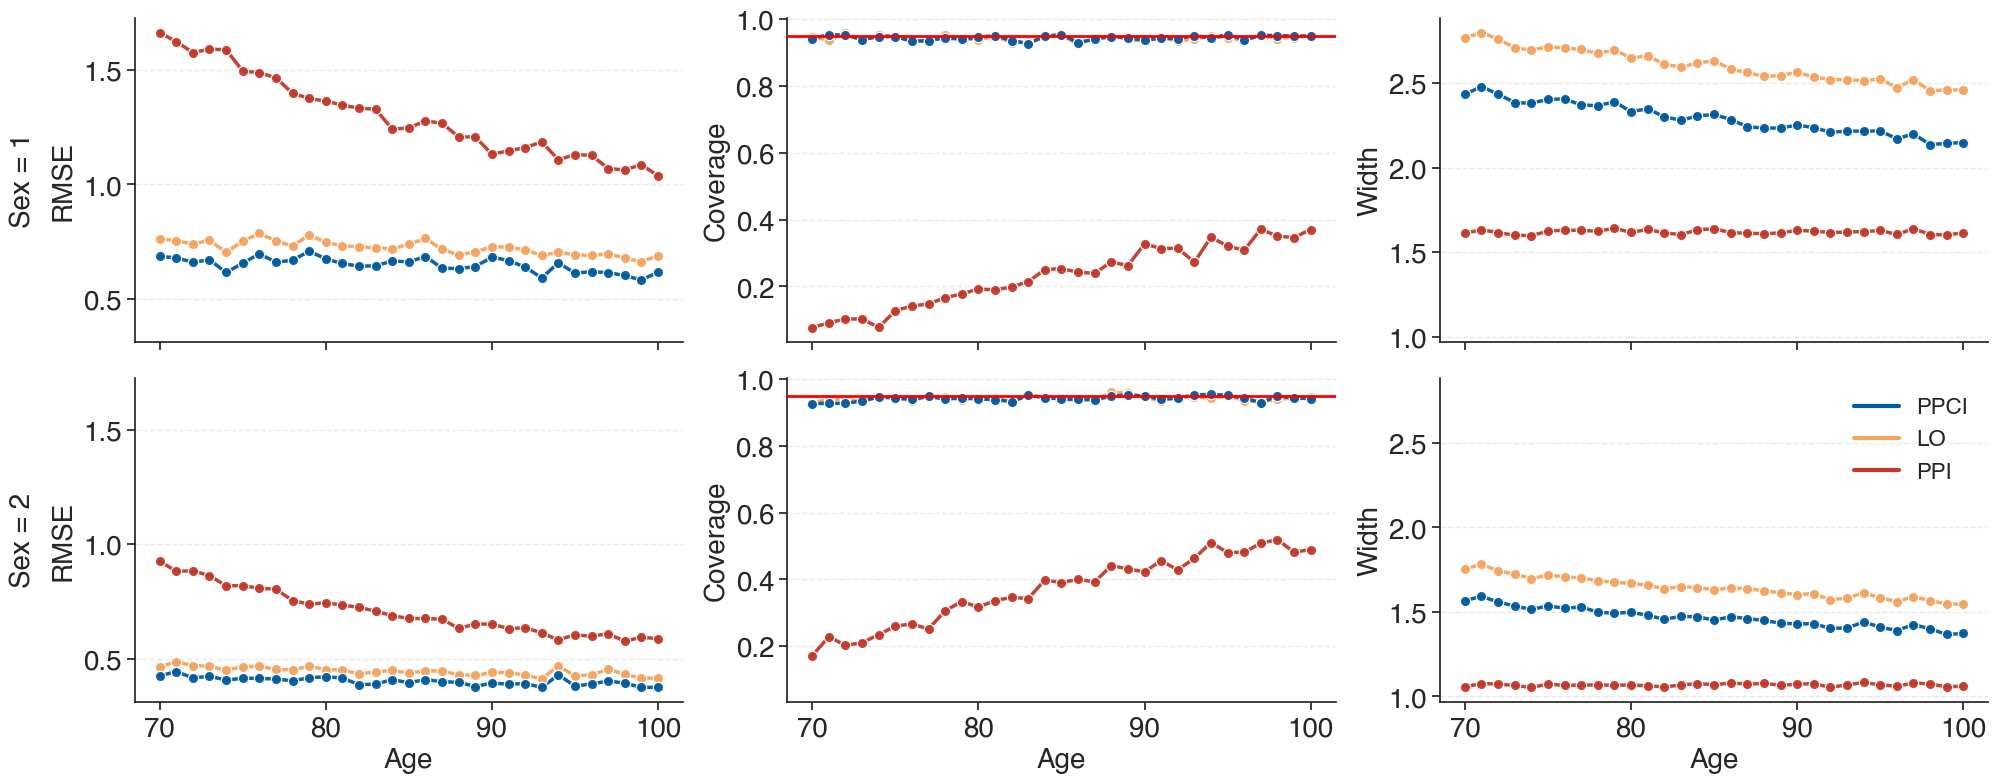

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 0. Font & plotting style configuration (force Helvetica)
# ==========================================
FONT_SIZE = 20
font_path = '/home/ysui8/yangsuienv/Helvetica.ttf'
custom_font_name = "Helvetica"  # Assume loaded successfully

if os.path.exists(font_path):
    try:
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        if prop.get_name() != 'Helvetica':
            raise ValueError("Loaded font name mismatch")
        print(f"✅ Font 'Helvetica' loaded successfully.")
    except Exception:
        raise FileNotFoundError(
            f"❌ Unable to load Helvetica font file '{font_path}'. Please ensure the path is correct and the file is valid."
        )
else:
    raise FileNotFoundError(f"❌ Helvetica font file '{font_path}' not found. Please check the path.")

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [custom_font_name]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# --- Keep your old behavior: math also in Helvetica ---
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = custom_font_name
mpl.rcParams['mathtext.it'] = f'{custom_font_name}:italic'
mpl.rcParams['mathtext.bf'] = f'{custom_font_name}:bold'

sns.set_theme(
    style="ticks",
    rc={
        "axes.grid": False,   # Disable global grid first; manually enable only horizontal grid later
        "font.sans-serif": [custom_font_name],
    },
)

# ==========================================
# 1. Read data: NEW CSV generated by run_census_income_ppci_mean_twofold_cf.py
# ==========================================
filename = "./results/census_income_ppci_mean_twofold_cf_checkpoint.csv"
df = pd.read_csv(filename)

# optional: keep only ok
if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

# Check required columns (NEW schema)
required_cols = [
    "age", "sex",
    "PPCI_theta_rmse", "PPCI_coverage", "PPCI_avg_ci_width",
    "LO_theta_rmse", "LO_coverage", "LO_avg_ci_width",
    "PPI_theta_rmse", "PPI_coverage", "PPI_avg_ci_width",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"❌ CSV is missing these columns: {missing}")

df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(int)

# ==========================================
# 2. Convert to long format: Method × Metric
# ==========================================
plot_data = []
for _, row in df.iterrows():
    age = int(row["age"])
    sex = int(row["sex"])

    # PPCI
    plot_data += [
        {"Age": age, "Sex": sex, "Method": "PPCI", "Metric": "RMSE",     "Value": float(row["PPCI_theta_rmse"])},
        {"Age": age, "Sex": sex, "Method": "PPCI", "Metric": "Coverage", "Value": float(row["PPCI_coverage"])},
        {"Age": age, "Sex": sex, "Method": "PPCI", "Metric": "Width",    "Value": float(row["PPCI_avg_ci_width"])},
    ]

    # LO (label-only)
    plot_data += [
        {"Age": age, "Sex": sex, "Method": "LO", "Metric": "RMSE",     "Value": float(row["LO_theta_rmse"])},
        {"Age": age, "Sex": sex, "Method": "LO", "Metric": "Coverage", "Value": float(row["LO_coverage"])},
        {"Age": age, "Sex": sex, "Method": "LO", "Metric": "Width",    "Value": float(row["LO_avg_ci_width"])},
    ]

    # PPI
    plot_data += [
        {"Age": age, "Sex": sex, "Method": "PPI", "Metric": "RMSE",     "Value": float(row["PPI_theta_rmse"])},
        {"Age": age, "Sex": sex, "Method": "PPI", "Metric": "Coverage", "Value": float(row["PPI_coverage"])},
        {"Age": age, "Sex": sex, "Method": "PPI", "Metric": "Width",    "Value": float(row["PPI_avg_ci_width"])},
    ]

df_long = pd.DataFrame(plot_data)

# ==========================================
# 3. Colors & smoothing function & plotting order
# ==========================================
palette = {
    "PPCI": "#005a9e",  # blue
    "LO":   "#f4a460",  # orange
    "PPI":  "#c0392b",  # red
}

# Plot order: draw LO first and PPCI last so PPCI points are on top
methods_plot = ["LO", "PPI", "PPCI"]
methods_legend = ["PPCI", "LO", "PPI"]

zorder_line = {"LO": 1, "PPI": 2, "PPCI": 3}
zorder_scatter = {"LO": 4, "PPI": 5, "PPCI": 6}

def smooth_line(x, y, num=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) <= 1:
        return x, y
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    x_new = np.linspace(x_sorted.min(), x_sorted.max(), num=num)
    y_new = np.interp(x_new, x_sorted, y_sorted)
    return x_new, y_new

metrics = ["RMSE", "Coverage", "Width"]

# ==========================================
# 4. 2×3: rows = Sex(1/2), cols = RMSE/Coverage/Width
# ==========================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 8),
    sharex='col',
    sharey='col'
)

for r, sex in enumerate([1, 2]):
    axes[r, 0].text(
        -0.18, 0.5,
        f"Sex = {sex}",
        transform=axes[r, 0].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=FONT_SIZE,
    )

    sub_sex = df_long[df_long["Sex"] == sex]

    for c, metric in enumerate(metrics):
        ax = axes[r, c]
        sub_metric = sub_sex[sub_sex["Metric"] == metric]

        for method in methods_plot:
            sub = sub_metric[sub_metric["Method"] == method].copy()
            if sub.empty:
                continue

            sub = sub.sort_values("Age")
            x = sub["Age"].values
            y = sub["Value"].values

            x_s, y_s = smooth_line(x, y, num=200)

            ax.plot(
                x_s, y_s,
                color=palette[method],
                linewidth=2.5,
                alpha=0.95,
                zorder=zorder_line[method],
            )
            ax.scatter(
                x, y,
                color=palette[method],
                marker="o",
                s=55,
                alpha=0.95,
                edgecolors="white",
                linewidths=0.9,
                zorder=zorder_scatter[method],
            )

        if metric == "Coverage":
            ax.axhline(
                0.95,
                color="red",
                linestyle="-",
                linewidth=2,
                zorder=10,
            )

        ax.set_ylabel(metric, fontsize=FONT_SIZE)
        ax.tick_params(axis='both', labelsize=FONT_SIZE)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontname(custom_font_name)

for c in range(3):
    axes[1, c].set_xlabel("Age", fontsize=FONT_SIZE)
    for label in axes[1, c].get_xticklabels():
        label.set_fontname(custom_font_name)

# ==========================================
# 5. Axis styling: keep only x/y spines + horizontal dashed gridlines only
# ==========================================
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.set_axisbelow(True)
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(False)

# ==========================================
# 6. Legend: bottom-right panel (Sex=2, Width)
# ==========================================
method_handles = [
    Line2D([0], [0], color=palette[m], linewidth=3, label=m)
    for m in methods_legend
]
axes[1, 2].legend(
    handles=method_handles,
    loc="upper right",
    fontsize=FONT_SIZE-4,
    frameon=False,
)

plt.tight_layout()
output_file = "income_mean_age_rmse_coverage_width.pdf"
plt.savefig(output_file, bbox_inches='tight', dpi=400)
print(f"✅ Figure saved as: {output_file}")
plt.show()

✅ Font 'Helvetica' loaded successfully.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


✅ Figure saved as: income_mean_age_sigma2_two_sex.pdf


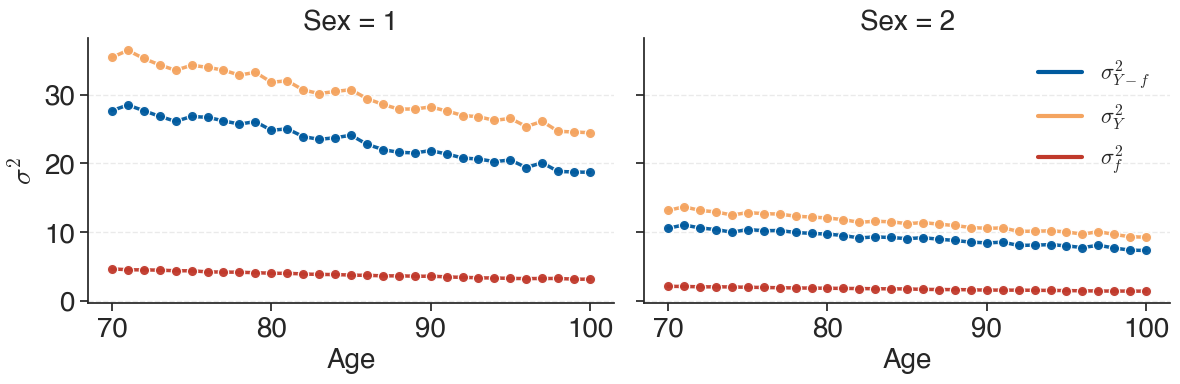

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import os
import numpy as np
from matplotlib.lines import Line2D

# ==========================================
# 0. Font & plotting style configuration
#    - Regular text: Helvetica
#    - Math text: Computer Modern (CMR) style
# ==========================================
FONT_SIZE = 20
font_path = '/home/ysui8/yangsuienv/Helvetica.ttf'
custom_font_name = "Helvetica"

if os.path.exists(font_path):
    try:
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        if prop.get_name() != 'Helvetica':
            raise ValueError("Loaded font name mismatch")
        print(f"✅ Font 'Helvetica' loaded successfully.")
    except Exception:
        raise FileNotFoundError(
            f"❌ Unable to load Helvetica font file '{font_path}'. Please ensure the path is correct and the file is valid."
        )
else:
    raise FileNotFoundError(f"❌ Helvetica font file '{font_path}' not found. Please check the path.")

# Regular text uses Helvetica
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = [custom_font_name]
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

# ✅ Math text uses CMR (no external LaTeX dependency)
mpl.rcParams["mathtext.fontset"] = "cm"

sns.set_theme(
    style="ticks",
    rc={
        "axes.grid": False,
        "font.sans-serif": [custom_font_name],
    },
)

# ==========================================
# 1. Read data: NEW census income results CSV
# ==========================================
filename = "./results/census_income_ppci_mean_twofold_cf_checkpoint.csv"
df = pd.read_csv(filename)

if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

required_cols = [
    "age", "sex",
    "PPCI_sigma2_Y_minus_f_mean",
    "PPCI_sigma2_f_mean",
    "LO_sigma2_Y_mean",
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"❌ CSV is missing these columns: {missing}")

df["age"] = df["age"].astype(int)
df["sex"] = df["sex"].astype(int)

# ==========================================
# 2. LaTeX (math) labels + colors
# ==========================================
label_Ymf = r"$\sigma^2_{Y-f}$"
label_Y   = r"$\sigma^2_Y$"
label_f   = r"$\sigma^2_f$"

palette = {
    label_Ymf: "#005a9e",  # blue
    label_Y:   "#f4a460",  # orange
    label_f:   "#c0392b",  # red
}

# Plot order: orange first, then red, and blue last (so blue points are on top)
series_plot = [label_Y, label_f, label_Ymf]
series_legend = [label_Ymf, label_Y, label_f]

zorder_line = {label_Y: 1, label_f: 2, label_Ymf: 3}
zorder_scatter = {label_Y: 4, label_f: 5, label_Ymf: 6}

def smooth_line(x, y, num=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) <= 1:
        return x, y
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    x_new = np.linspace(x_sorted.min(), x_sorted.max(), num=num)
    y_new = np.interp(x_new, x_sorted, y_sorted)
    return x_new, y_new

# ==========================================
# 3. One row with two panels: Sex=1 / Sex=2
# ==========================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharey=True
)

for j, sex in enumerate([1, 2]):
    ax = axes[j]
    sub = df[df["sex"] == sex].sort_values("age")
    if sub.empty:
        raise ValueError(f"❌ No data for sex={sex}.")

    x = sub["age"].values

    for name in series_plot:
        if name == label_Ymf:
            y = sub["PPCI_sigma2_Y_minus_f_mean"].values
        elif name == label_f:
            y = sub["PPCI_sigma2_f_mean"].values
        elif name == label_Y:
            y = sub["LO_sigma2_Y_mean"].values
        else:
            continue

        x_s, y_s = smooth_line(x, y, num=200)

        ax.plot(
            x_s, y_s,
            color=palette[name],
            linewidth=2.5,
            alpha=0.95,
            zorder=zorder_line[name],
        )
        ax.scatter(
            x, y,
            color=palette[name],
            marker="o",
            s=55,
            alpha=0.95,
            edgecolors="white",
            linewidths=0.9,
            zorder=zorder_scatter[name],
        )

    ax.set_title(f"Sex = {sex}", fontsize=FONT_SIZE)
    ax.set_xlabel("Age", fontsize=FONT_SIZE)
    ax.tick_params(axis='both', labelsize=FONT_SIZE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname(custom_font_name)

axes[0].set_ylabel(r"$\sigma^2$", fontsize=FONT_SIZE)
for label in axes[0].get_yticklabels():
    label.set_fontname(custom_font_name)

# ==========================================
# 4. Axis styling: keep only x/y spines + horizontal dashed gridlines only
# ==========================================
for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    ax.set_axisbelow(True)
    ax.grid(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(False)

# ==========================================
# 5. Legend
# ==========================================
handles = [
    Line2D([0], [0], color=palette[name], linewidth=3, label=name)
    for name in series_legend
]
axes[1].legend(
    handles=handles,
    loc="upper right",
    fontsize=FONT_SIZE-4,
    frameon=False,
)

plt.tight_layout()
output_file = "income_mean_age_sigma2_two_sex.pdf"
plt.savefig(output_file, bbox_inches='tight', dpi=400)
print(f"✅ Figure saved as: {output_file}")
plt.show()